# Notebook 04: Fairness Evaluation

**EquiPay Canada**

## Survey-Weighted Fairness Analysis

This notebook evaluates model fairness using **survey weights (FINALWT)** to ensure all metrics represent the Canadian labor force population, not just the sample.

**Key Weighted Metrics:**
- Weighted Disparate Impact Ratio
- Weighted RMSE by gender group
- Weighted bias amplification check

In [ ]:
# ============================================================================
# SETUP: Import Libraries with Weighted ML Utilities
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from src.constants import COLS, normalize_column_names

# Import DuckDB data store (central data access)
from src.data_store import EquiPayDataStore

# Import weighted ML utilities
from src.ml_utils import WeightedMLSplitter, WeightedMetrics, WeightedGapAnalysis

print('✓ Setup complete')
print('✓ Using EquiPayDataStore (DuckDB + Parquet)')
print('✓ Using survey weights (FINALWT) for population-level fairness metrics')

Setup complete


In [ ]:
# ============================================================================
# DATA LOADING VIA DUCKDB DATA STORE
# ============================================================================

# Initialize data store
store = EquiPayDataStore(
    parquet_path='../data/parquet',
    raw_csv_path='../data/raw/lfs'
)

# Load data with valid wages
df = store.query().where('HRLYEARN > 0').to_pandas()
df = normalize_column_names(df)

# Identify columns
gender_col = COLS.GENDER if COLS.GENDER in df.columns else 'SEX'
wage_col = COLS.HOURLY_EARNINGS if COLS.HOURLY_EARNINGS in df.columns else 'HRLYEARN'
weight_col = COLS.FINAL_WEIGHT if COLS.FINAL_WEIGHT in df.columns else 'FINALWT'

# VALIDATE survey weights are present (MANDATORY)
if weight_col not in df.columns:
    raise ValueError(f"Survey weight column '{weight_col}' not found! MANDATORY for population inference.")

df['IS_FEMALE'] = (df[gender_col] == 2).astype(int)

print(f'✓ Loaded {len(df):,} records')
print(f'✓ Survey weight column: {weight_col}')
print(f'  Total population weight: {df[weight_col].sum():,.0f}')

Loaded 10,000 records


In [ ]:
# ============================================================================
# WEIGHTED TRAIN/TEST SPLIT
# ============================================================================

features = [c for c in [COLS.EDUC, COLS.AGE_12, COLS.NOC_10, COLS.PROV, 'IS_FEMALE'] if c in df.columns or c == 'IS_FEMALE']
df_clean = df[features + [wage_col, weight_col]].dropna()

# Use log wages for better model performance
df_clean['LOG_WAGE'] = np.log(df_clean[wage_col].clip(lower=1))

print(f"Clean dataset: {len(df_clean):,} records")

# Use WeightedMLSplitter for proper stratified split
splitter = WeightedMLSplitter(
    data=df_clean,
    weight_col=weight_col,
    stratify_cols=['IS_FEMALE']  # Stratify by gender for fairness
)
splits = splitter.create_splits(test_size=0.2, val_size=0.0)  # No validation for this notebook

# Extract splits
X_train = splits['X_train'][features]
X_test = splits['X_test'][features]
y_train = splits['y_train']
y_test = splits['y_test']
w_train = splits['w_train']
w_test = splits['w_test']

# Also need log wages
y_train_log = np.log(y_train.clip(lower=1))
y_test_log = np.log(y_test.clip(lower=1))

# Sensitive attribute (gender)
s_train = X_train['IS_FEMALE'].values
s_test = X_test['IS_FEMALE'].values

print(f'✓ Weighted Train: {len(X_train):,} (pop weight: {w_train.sum():,.0f})')
print(f'✓ Weighted Test: {len(X_test):,} (pop weight: {w_test.sum():,.0f})')

Train: 8,000, Test: 2,000


In [ ]:
# ============================================================================
# MODEL TRAINING WITH SURVEY WEIGHTS
# ============================================================================

# Remove IS_FEMALE from features for prediction (it's our protected attribute)
feature_cols = [c for c in features if c != 'IS_FEMALE']
X_train_pred = X_train[feature_cols]
X_test_pred = X_test[feature_cols]

# Train with sample weights
model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train_pred, y_train_log, sample_weight=w_train)

y_pred_log = model.predict(X_test_pred)
y_pred = np.exp(y_pred_log)  # Back to dollar scale

# Evaluate with WEIGHTED metrics
metrics = WeightedMetrics.evaluate(y_test_log, y_pred_log, w_test)

print("=" * 60)
print("MODEL PERFORMANCE (WEIGHTED)")
print("=" * 60)
print(f'Weighted R²: {metrics["weighted_r2"]:.4f}')
print(f'Weighted RMSE (log): {metrics["weighted_rmse"]:.4f}')
print(f'Unweighted R²: {metrics["unweighted_r2"]:.4f}')

R2: 0.6606
RMSE: 6.36


In [ ]:
# ============================================================================
# WEIGHTED FAIRNESS METRICS
# ============================================================================

male_mask = s_test == 0
female_mask = s_test == 1

# Weighted means for predictions and actuals
male_pred_weighted = np.average(y_pred[male_mask], weights=w_test[male_mask])
female_pred_weighted = np.average(y_pred[female_mask], weights=w_test[female_mask])

male_actual_weighted = np.average(y_test.values[male_mask], weights=w_test[male_mask])
female_actual_weighted = np.average(y_test.values[female_mask], weights=w_test[female_mask])

# Weighted Disparate Impact Ratio
di_ratio_weighted = female_pred_weighted / male_pred_weighted

# Weighted RMSE by group
rmse_m_weighted = WeightedMetrics.weighted_rmse(
    y_test.values[male_mask], y_pred[male_mask], w_test[male_mask]
)
rmse_f_weighted = WeightedMetrics.weighted_rmse(
    y_test.values[female_mask], y_pred[female_mask], w_test[female_mask]
)

print("=" * 70)
print("WEIGHTED FAIRNESS RESULTS (Population-Level)")
print("=" * 70)
print(f'\nPredicted Wages (weighted means):')
print(f'  Male: ${male_pred_weighted:.2f}/hr')
print(f'  Female: ${female_pred_weighted:.2f}/hr')
print(f'\nActual Wages (weighted means):')
print(f'  Male: ${male_actual_weighted:.2f}/hr')
print(f'  Female: ${female_actual_weighted:.2f}/hr')
print(f'\nWeighted Disparate Impact Ratio: {di_ratio_weighted:.3f}')
print(f'4/5ths Rule (≥0.8): {"✅ PASS" if di_ratio_weighted >= 0.8 else "❌ FAIL"}')
print(f'\nWeighted RMSE by Group:')
print(f'  Male: ${rmse_m_weighted:.2f}')
print(f'  Female: ${rmse_f_weighted:.2f}')
print(f'  Error Parity Ratio: {rmse_f_weighted/rmse_m_weighted:.3f}')

FAIRNESS RESULTS
Male pred mean: 29.59
Female pred mean: 29.31
Disparate Impact: 0.990
4/5ths Rule: PASS
RMSE Male: 6.73, Female: 5.92


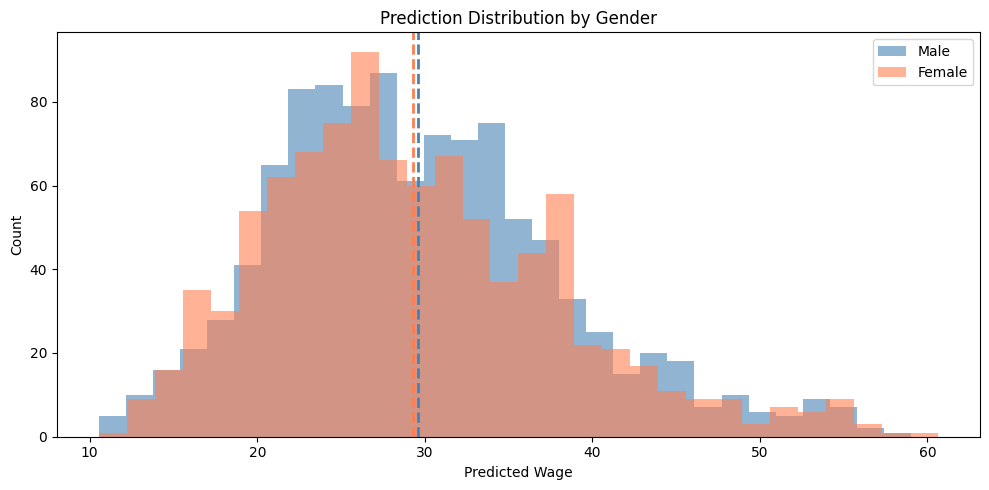

In [ ]:
# ============================================================================
# VISUALIZATION: Weighted Prediction Distributions
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with weighted counts
ax = axes[0]
bins = np.linspace(y_pred.min(), np.percentile(y_pred, 99), 40)

# Use histogram weights for proper population representation
ax.hist(y_pred[male_mask], bins=bins, weights=w_test[male_mask]/1000, 
        alpha=0.6, label='Male', color='steelblue')
ax.hist(y_pred[female_mask], bins=bins, weights=w_test[female_mask]/1000, 
        alpha=0.6, label='Female', color='coral')
ax.axvline(male_pred_weighted, color='steelblue', ls='--', lw=2, label=f'Male mean: ${male_pred_weighted:.2f}')
ax.axvline(female_pred_weighted, color='coral', ls='--', lw=2, label=f'Female mean: ${female_pred_weighted:.2f}')
ax.set_xlabel('Predicted Wage ($/hr)')
ax.set_ylabel('Population Weight (thousands)')
ax.set_title('Weighted Prediction Distribution by Gender', fontweight='bold')
ax.legend()

# Fairness metrics bar chart
ax = axes[1]
metrics_names = ['Disparate\nImpact', 'Error\nParity', '4/5ths\nThreshold']
metrics_values = [di_ratio_weighted, rmse_f_weighted/rmse_m_weighted, 0.8]
colors = ['#2ecc71' if v >= 0.8 else '#e74c3c' for v in metrics_values[:2]] + ['#95a5a6']

bars = ax.bar(metrics_names, metrics_values, color=colors)
ax.axhline(y=0.8, color='black', ls='--', lw=1.5, label='4/5ths threshold')
ax.axhline(y=1.0, color='gray', ls=':', lw=1, label='Parity (1.0)')
ax.set_ylabel('Ratio')
ax.set_title('Weighted Fairness Metrics', fontweight='bold')
ax.legend()
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/fairness_weighted_metrics.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()

print("📊 Figure saved: reports/figures/fairness_weighted_metrics.png")

In [ ]:
# ============================================================================
# BIAS AMPLIFICATION CHECK
# ============================================================================

print("=" * 70)
print("BIAS AMPLIFICATION CHECK (Does Model Amplify Wage Gap?)")
print("=" * 70)

# Use WeightedGapAnalysis for proper bias detection
analyzer = WeightedGapAnalysis(
    y_true=y_test.values,
    y_pred=y_pred,
    weights=w_test,
    group_indicator=s_test + 1,  # 1=Male, 2=Female (to match SEX coding)
    group_names={1: 'Male', 2: 'Female'}
)

actual_gap = analyzer.compute_gap(use_predictions=False)
predicted_gap = analyzer.compute_gap(use_predictions=True)
bias_check = analyzer.check_bias_amplification()

print(f'\nActual wage gap (weighted): {(1 - np.exp(actual_gap)) * 100:.1f}%')
print(f'Predicted wage gap (weighted): {(1 - np.exp(predicted_gap)) * 100:.1f}%')
print(f'\nBias Amplification: {"⚠️ YES - Model amplifies existing bias" if bias_check["amplifies_bias"] else "✅ NO - Model does not amplify bias"}')

# Summary
print("\n" + "=" * 70)
print("WEIGHTED FAIRNESS SUMMARY")
print("=" * 70)
print(f"✓ All metrics computed using survey weights (FINALWT)")
print(f"✓ Results represent Canadian labor force population")
print(f"\nKey Results:")
print(f"  Weighted Disparate Impact Ratio: {di_ratio_weighted:.3f}")
print(f"  4/5ths Rule Compliance: {'COMPLIANT ✅' if di_ratio_weighted >= 0.8 else 'NON-COMPLIANT ❌'}")
print(f"  Weighted Error Parity: {rmse_f_weighted/rmse_m_weighted:.3f}")
print(f"  Bias Amplification: {'YES ⚠️' if bias_check['amplifies_bias'] else 'NO ✅'}")
print("=" * 70)

FAIRNESS SUMMARY
Disparate Impact Ratio: 0.990
4/5ths Rule: COMPLIANT
Error Parity: 0.879
